# 7. Link to Other Indices

In this section, the Startup Viability Index (SVI) is compared with established global composite indicators to assess whether it aligns with recognised measures of innovation and entrepreneurial ecosystem strength.

The purpose is not to replicate these indices, but to externally validate the SVI by checking whether countries that score highly on SVI also tend to perform well on similar international benchmarks.


## 7.1 Selected External Indices

### Global Innovation Index (GII)
The Global Innovation Index measures the innovation performance of countries, covering areas such as technology, knowledge creation, infrastructure, and creative outputs.

> Source: https://www.wipo.int/global_innovation_index/en/

This index is used as a benchmark for national innovation capacity and is closely related to the technological and productivity dimensions of the SVI.

### Global Entrepreneurship Index (GEI)
The Global Entrepreneurship Index evaluates the strength and quality of entrepreneurial ecosystems, including opportunity perception, startup skills, risk acceptance, and innovation support.

> Source: https://thegedi.org/global-entrepreneurship-and-development-index/

This index is particularly relevant for validating the entrepreneurial and business-environment aspects of the SVI.


## 7.2 Methodological Caveats

Before performing the comparison, several limitations should be acknowledged:

- **Time mismatch:** The external indices are from different publication years (e.g. GII 2024 and GEI 2018), while the SVI is based on indicators spanning 2016-2025. Therefore, the comparison is cross-sectional rather than time-aligned.

- **Different methodologies:** Each index uses different variables, weighting schemes, and aggregation methods. As a result, the analysis focuses on directional consistency rather than exact numerical equivalence.

- **Coverage differences:** The number of countries included may differ across datasets, which can affect sample consistency during merging.

## 7.3 Analytical Approach

The comparison between SVI and external indices will be conducted as follows:

- Standardise country names across datasets  
- Merge datasets at country level  
- Compute Pearson and Spearman correlation coefficients  
- Visualise relationships using scatter plots  
- Interpret consistency between rankings and index values  


## 7.4 Objective of This Section

This section provides an external validation of the SVI by assessing whether it aligns with established global measures of innovation and entrepreneurship. Strong positive correlations would suggest that the SVI is capturing meaningful structural differences across countries in line with recognised indices.

## 7.5 Merging SVI with External Indices

To compare the Startup Viability Index (SVI) with established global benchmarks, the dataset is merged with two external composite indicators: the **Global Innovation Index (GII)** and the **Global Entrepreneurship Index (GEI)**.

Since each dataset uses different country identifiers (ISO3 codes vs country names), a standardisation step is required before merging. The aim is to ensure consistent country-level matching across all indices.

After standardising country names, a unified dataset is constructed containing:

- Startup Viability Index (SVI)
- Global Innovation Index (GII)
- Global Entrepreneurship Index (GEI)

This merged dataset forms the basis for correlation analysis and visual comparison in the following section.

In [8]:
import pandas as pd

svi = pd.read_csv("../data/results/startup_viability_index.csv")
gii = pd.read_excel("../data/external_indices/global_innovation_index.xlsx")
gei = pd.read_excel("../data/external_indices/global_entrepreneurship_index.xlsx")

# Clean GII
gii_clean = gii[["ECONOMY_NAME", "SCORE"]].copy()
gii_clean.columns = ["Country", "GII"]
    
# Clean GEI
gei_clean = gei[["Country", "GEI"]].copy()

# Clean SVI
svi_clean = svi[["Country Name", "Startup_Viability_Index"]].copy()
svi_clean.columns = ["Country", "SVI"]

# Standardize country names
def clean_country(x):
    return x.strip().lower()

svi_clean["Country"] = svi_clean["Country"].apply(clean_country)
gii_clean["Country"] = gii_clean["Country"].apply(clean_country)
gei_clean["Country"] = gei_clean["Country"].apply(clean_country)

# Merge datasets
df_merged = svi_clean.merge(gii_clean, on="Country", how="inner")
df_merged = df_merged.merge(gei_clean, on="Country", how="inner")

# Final clean
df_merged = df_merged.dropna()

# Reset index
df_merged = df_merged.reset_index(drop=True)

print("Merged dataset shape:", df_merged.shape)
df_merged.head()

df_merged.to_csv("../data/results/svi_external_indices_merged.csv", index=False)
print("Merged dataset saved successfully.")

Merged dataset shape: (103, 4)
Merged dataset saved successfully.


## 7.6 Correlation Analysis

To assess the validity of the Startup Viability Index (SVI), I compute correlations with established international indicators (GEI and GII).

A positive correlation would suggest that countries scoring highly on SVI also tend to perform well on recognised innovation and entrepreneurship indices, supporting the external validity of the measure.

Both Pearson and Spearman correlations are used:
- Pearson: linear relationship between scores
- Spearman: rank-based relationship (more robust to outliers and non-linearity)

In [12]:
df = pd.read_csv("../data/results/svi_external_indices_merged.csv")
df.columns = df.columns.str.strip()

# Correlation matrix
corr_pearson = df[["SVI", "GEI", "GII"]].corr(method="pearson")
corr_spearman = df[["SVI", "GEI", "GII"]].corr(method="spearman")

print("===================================================")
print("             Pearson Correlation Matrix")
print("===================================================")
print(corr_pearson)

print("\n===================================================")
print("            Spearman Correlation Matrix")
print("===================================================")
print(corr_spearman)

             Pearson Correlation Matrix
          SVI       GEI       GII
SVI  1.000000  0.837979  0.917695
GEI  0.837979  1.000000  0.888507
GII  0.917695  0.888507  1.000000

            Spearman Correlation Matrix
          SVI       GEI       GII
SVI  1.000000  0.878366  0.948315
GEI  0.878366  1.000000  0.882155
GII  0.948315  0.882155  1.000000


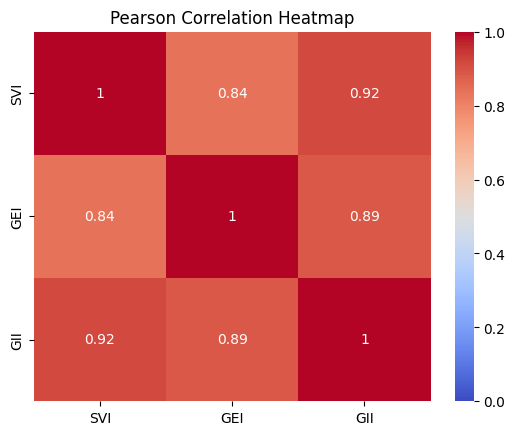

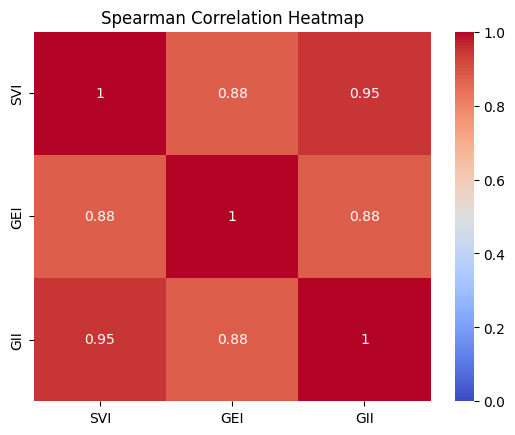

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../artifacts/index_comparisons", exist_ok=True)

# Correlation matrices 
corr_pearson = df[["SVI", "GEI", "GII"]].corr(method="pearson")
corr_spearman = df[["SVI", "GEI", "GII"]].corr(method="spearman")

# Pearson Heatmap
plt.figure()
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.savefig("../artifacts/index_comparisons/pearson_heatmap_svi.png", dpi=300)
plt.show()

# Spearman Heatmap
plt.figure()
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Spearman Correlation Heatmap")
plt.savefig("../artifacts/index_comparisons/spearman_heatmap_svi.png", dpi=300)
plt.show()

## 7.7 Country Ranking Comparison

To further assess the consistency of the Startup Viability Index (SVI), I compare country rankings across SVI, GEI, and GII.

This helps identify whether countries that perform well on SVI also appear in the top or bottom ranks of established global indices.

The comparison highlights:
- Common high-performing countries across all indices
- Structural differences between startup viability, innovation, and entrepreneurship measures

In [23]:
# Rank countries in each index
df["SVI_rank"] = df["SVI"].rank(ascending=False)
df["GEI_rank"] = df["GEI"].rank(ascending=False)
df["GII_rank"] = df["GII"].rank(ascending=False)

# Top 10 SVI countries
top_svi = df.sort_values("SVI", ascending=False).head(10)

print("===================================================")
print("             Top 10 Countries by SVI")
print("===================================================")
print(top_svi[["Country", "SVI", "GEI", "GII"]].to_string(index=False))

             Top 10 Countries by SVI
       Country      SVI      GEI       GII
     singapore 0.689202 0.527036 61.181024
   switzerland 0.672583 0.804472 67.473082
       denmark 0.661012 0.743097 57.114019
         china 0.659486 0.411443 56.322730
        norway 0.652871 0.566091 49.060133
       iceland 0.651246 0.741506 48.543765
        sweden 0.649806 0.731051 64.524365
     australia 0.648738 0.754537 48.096089
         japan 0.643657 0.515181 54.123504
united kingdom 0.636734 0.777543 61.049318


In [24]:
# Bottom 10 SVI countries
bottom_svi = df.sort_values("SVI", ascending=True).head(10)

print("===================================================")
print("             Bottom 10 Countries by SVI")
print("===================================================")
print(bottom_svi[["Country", "SVI", "GEI", "GII"]].to_string(index=False))

             Bottom 10 Countries by SVI
     Country      SVI      GEI       GII
     burundi 0.272333 0.118262 13.205343
  mozambique 0.289528 0.140131 13.109185
burkina faso 0.290679 0.131650 12.755502
  madagascar 0.303036 0.140123 17.934865
      angola 0.306832 0.144067 10.216209
        mali 0.308710 0.158594 11.794625
      uganda 0.309156 0.128524 14.944522
    pakistan 0.312630 0.156412 22.006101
      zambia 0.315491 0.195808 15.664772
       ghana 0.316882 0.211771 20.034737
